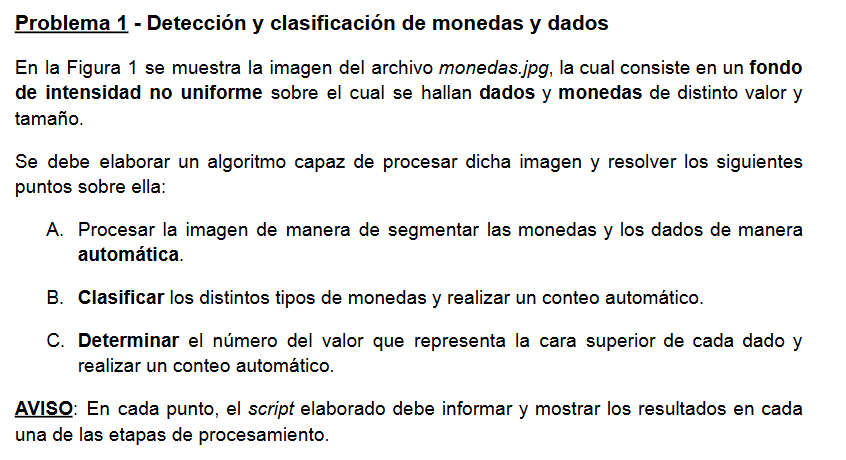

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import math

# PARTE A

In [3]:
img = cv2.imread('img/monedas.jpg')

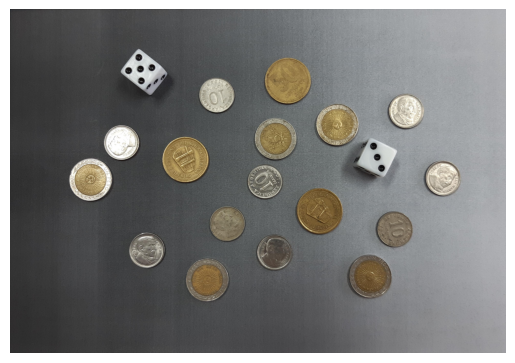

In [4]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [5]:
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

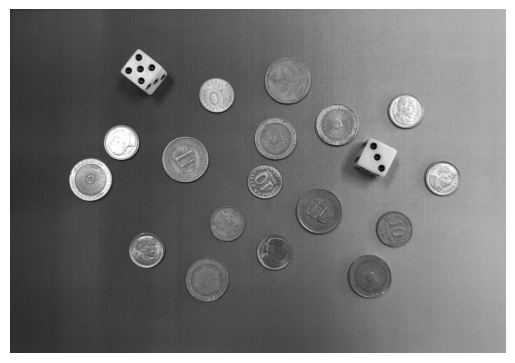

In [6]:
plt.imshow(img_gris, cmap='gray')
plt.axis('off')
plt.show()

In [7]:
# filtro gaussiano
img_gris_blur = cv2.GaussianBlur(img_gris, (9, 9), 2)

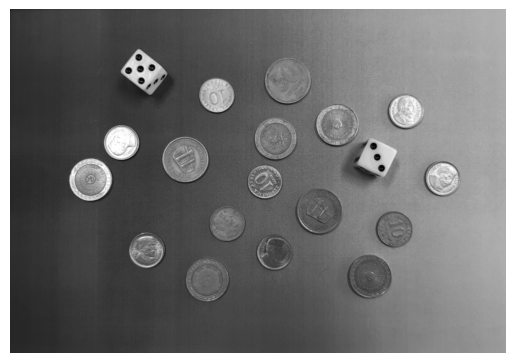

In [8]:
plt.imshow(img_gris_blur, cmap='gray')
plt.axis('off')
plt.show()

umbralado de la practica pdi_u3_segmentacion.py

con  cv2.threshold()

https://docs.opencv.org/4.x/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57

100.0
uint8
[  0 255]


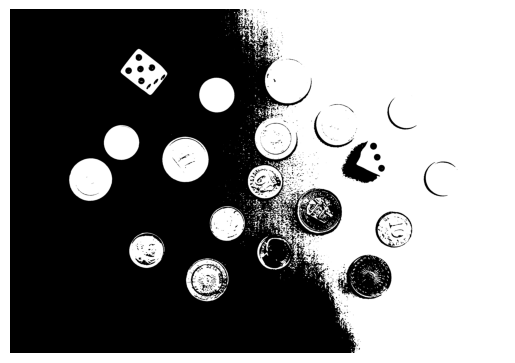

In [9]:
th_out, img_umbralado = cv2.threshold(img_gris_blur, thresh=100, maxval=255, type=cv2.THRESH_BINARY)
print(th_out)
print(img_umbralado.dtype)
print(np.unique(img_umbralado))
plt.imshow(img_umbralado, cmap='gray')
plt.axis('off')
plt.show()

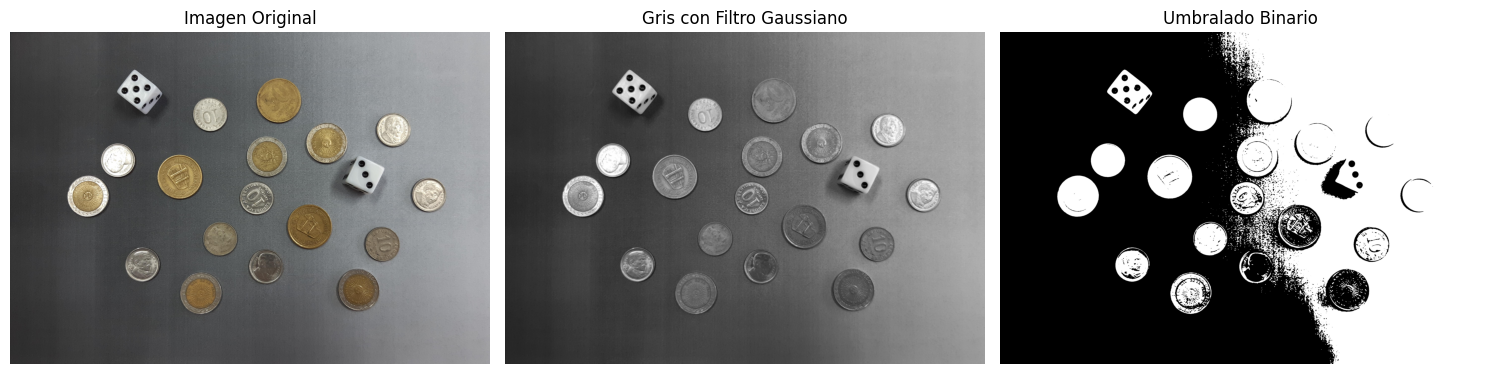

In [10]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gris_blur, cmap='gray')
plt.title('Gris con Filtro Gaussiano')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_umbralado, cmap='gray')
plt.title('Umbralado Binario')
plt.axis('off')

plt.tight_layout()
plt.show()


 cv2.adaptiveThreshold(

   imagen_fuente (grises),

   valor_maximo (255, blanco),

   metodo_adaptativo (cv2.ADAPTIVE_THRESH_GAUSSIAN_C -> mejor para iluminación variable),

   tipo_umbral (cv2.THRESH_BINARY_INV -> Invertido, queremos objetos blancos),

   tamano_bloque (ej. 31x31 píxeles, debe ser impar),
   
   C (constante a restar de la media, ajusta la sensibilidad)
 )

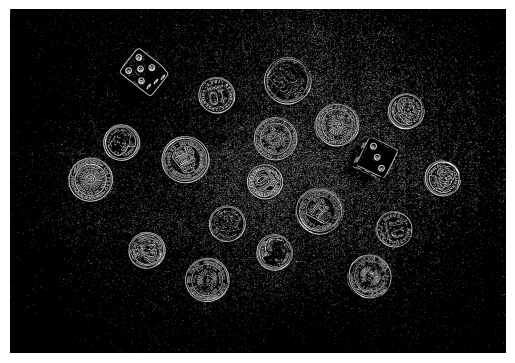

In [11]:
# hay que hacer umbralado local (vecinos)
img_umbralado_oscuro = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,   # objetos oscuros
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

plt.imshow(img_umbralado_oscuro, cmap='gray')
plt.axis('off')
plt.show()

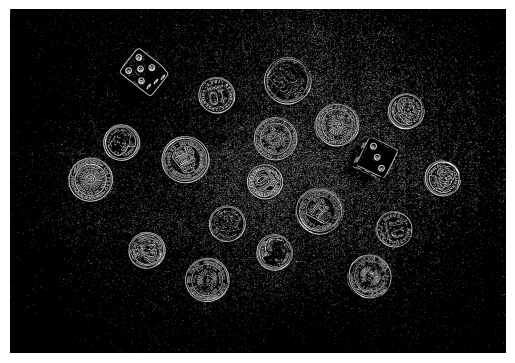

In [12]:
# hay que hacer umbralado local (vecinos)
img_umbralado_blancos = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,   # objetos blancos
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

celda_invertida = 255 - img_umbralado_blancos

plt.imshow(celda_invertida, cmap='gray')
plt.axis('off')
plt.show()

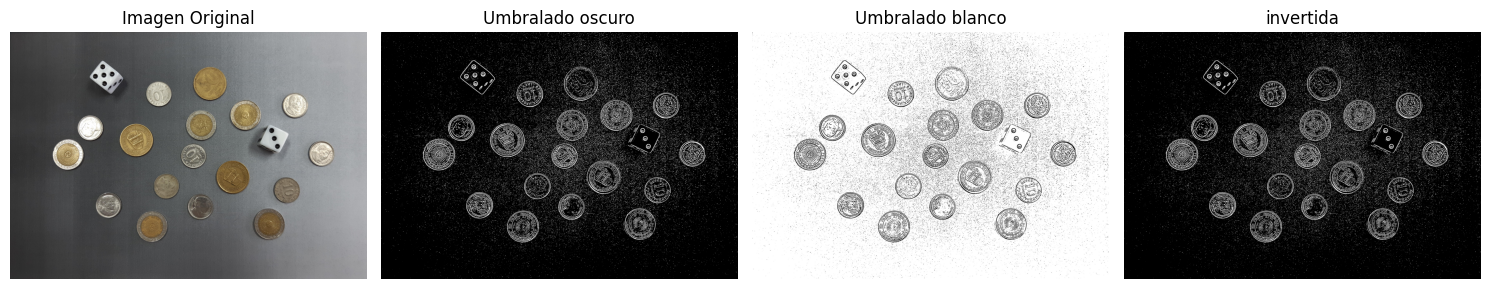

In [13]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_umbralado_oscuro, cmap='gray')
plt.title('Umbralado oscuro')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_umbralado_blancos, cmap='gray')
plt.title('Umbralado blanco')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(celda_invertida, cmap='gray')
plt.title('invertida')
plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
# componentes conectadas
(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    celda_invertida,
    connectivity=8,
    ltype=cv2.CV_32S
)
print(num_labels, labels, stats, centroids)
img_umbralado_blancos.shape

46634 [[0 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] [[      0       0    3871    2681 9567848]
 [      0       0       3       8      18]
 [    211       0       3       3       6]
 ...
 [   2352    2678       3       3       4]
 [   2828    2679       3       2       3]
 [   3540    2678       4       3       6]] [[1.92350460e+03 1.34702231e+03]
 [7.77777778e-01 3.44444444e+00]
 [2.12166667e+02 8.33333333e-01]
 ...
 [2.35300000e+03 2.67875000e+03]
 [2.82900000e+03 2.67933333e+03]
 [3.54150000e+03 2.67916667e+03]]


(2681, 3871)

In [15]:
copia_img = img.copy()

In [ ]:
def encontrar_figuras(imagen, AREA_MINIMA_VALIDA, AREA_MAXIMA_VALIDA):

    objetos_contados = 0 

    conteo_areas={}

    recortes_para_ensamblar = []

    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img_gris_blur = cv2.GaussianBlur(img_gris, (9, 9), 2)

    img_umbralado_blancos = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,   # objetos blancos
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

    celda_invertida = 255 - img_umbralado_blancos

    (num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    celda_invertida,
    connectivity=8,
    ltype=cv2.CV_32S
)

    for i in range(1, num_labels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]


        if AREA_MAXIMA_VALIDA > area >= AREA_MINIMA_VALIDA:

            #area_agrupada = int((area // 100.0)* 100) 
            area_agrupada = int(math.ceil(area / 100.0)) * 100

            if area_agrupada in conteo_areas:
                conteo_areas[area_agrupada] += 1
            
            else:
                conteo_areas[area_agrupada] = 1
    
            objetos_contados += 1 

            cv2.rectangle(imagen, (x, y), (x + w, y + h), (0, 255, 0), 2)

            (cX, cY) = centroids[i]
            cv2.putText(imagen, str(objetos_contados), (int(cX) - 10, int(cY)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            
            objeto_recortado = imagen[y:y + h, x:x + w]
            
            recortes_para_ensamblar.append(objeto_recortado)
            
            nombre_ventana = f"Objeto {objetos_contados} (Area: {area_agrupada})"
            #cv2.imshow(nombre_ventana, objeto_recortado)


    return  objetos_contados, conteo_areas #, imagen_ensamblada_recortes
  
print(encontrar_figuras(copia_img, 2550, 4800))



(19, {4800: 1, 4600: 1, 3800: 2, 3500: 1, 3000: 1, 2600: 4, 3400: 2, 4100: 1, 4200: 1, 3200: 1, 2700: 1, 4500: 2, 3700: 1})


In [68]:
def encontrar_objetos(img, AREA_MINIMA_VALIDA, AREA_MAXIMA_VALIDA, umbral_global, kernel):
    
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    kernel_tophat = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel, kernel))
    img_tophat = cv2.morphologyEx(img_gris, cv2.MORPH_TOPHAT, kernel_tophat)
    img_gris_blur = cv2.GaussianBlur(img_tophat, (3, 3), 0)
    
    ret, img_umbralado = cv2.threshold(img_gris_blur, umbral_global, 255, cv2.THRESH_BINARY)
    
    kernel_cierre = np.ones((5, 5), np.uint8) 
    celda_cerrada = cv2.morphologyEx(img_umbralado, cv2.MORPH_CLOSE, kernel_cierre)
    kernel_apertura = np.ones((3, 3), np.uint8)
    celda_limpia = cv2.morphologyEx(celda_cerrada, cv2.MORPH_OPEN, kernel_apertura)
    
    
    (num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
        celda_limpia, connectivity=8, ltype=cv2.CV_32S
    )
    
    objetos_validos = []
    
    # bucle componentes y  filtro de área
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        if AREA_MAXIMA_VALIDA > area >= AREA_MINIMA_VALIDA:
            
            objetos_validos.append({
                'id': i,
                'area': area,
                'stats': stats[i],
                'centroid': centroids[i]
            })

    
    
    # ordena los objetos válidos por área de mayor a menor
    objetos_validos.sort(key=lambda x: x['area'], reverse=True)
    
   
    num_dados = 2 
    
    objetos_contados = 0
    contador_areas = {}
    contador_tipos = {"Moneda": 0, "Dado": 0, "Otros": 0} 
    recortes_para_ensamblar = []
    img_resultado = img.copy()
    
    for idx, objeto in enumerate(objetos_validos):
        
        
        if idx < num_dados:
            tipo_objeto = "Dado"
            color_rectangulo = (0, 0, 255) 
            contador_tipos["Dado"] += 1
        else:
            tipo_objeto = "Moneda" 
            color_rectangulo = (0, 255, 0)
            contador_tipos["Moneda"] += 1

        
        x = objeto['stats'][cv2.CC_STAT_LEFT]
        y = objeto['stats'][cv2.CC_STAT_TOP]
        w = objeto['stats'][cv2.CC_STAT_WIDTH]
        h = objeto['stats'][cv2.CC_STAT_HEIGHT]
        area = objeto['area']
        
        objetos_contados += 1 

        area_agrupada = int(math.ceil(area / 100.0)) * 100
        contador_areas[area_agrupada] = contador_areas.get(area_agrupada, 0) + 1
        
        cv2.rectangle(img_resultado, (x, y), (x + w, y + h), color_rectangulo, 2)
        (cX, cY) = objeto['centroid']
        etiqueta = f"{objetos_contados}:{tipo_objeto[0]}"
        cv2.putText(img_resultado, etiqueta, (int(cX) - 10, int(cY)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        objeto_recortado = img[y:y + h, x:x + w]
        recortes_para_ensamblar.append(objeto_recortado)

    
    print(" Segmentación con Top-Hat y clausura ")
    print(f"Objetos detectados válidos: {objetos_contados}")
    print(f"Contador por tipo (final): {contador_tipos}")
    print(f"Contador por área agrupada: {contador_areas}")
    # cv2.imshow("A. Objetos Segmentados (Clasificación Final)", img_resultado)

    return objetos_contados, contador_areas, contador_tipos, recortes_para_ensamblar, img_resultado

encontrar_objetos(copia_img, 900, 20000, 50, 71)

 Segmentación con Top-Hat y clausura 
Objetos detectados válidos: 19
Contador por tipo (final): {'Moneda': 17, 'Dado': 2, 'Otros': 0}
Contador por área agrupada: {12900: 1, 10200: 1, 8900: 1, 8100: 1, 6800: 1, 6500: 1, 5500: 2, 5300: 1, 3400: 1, 3300: 1, 3000: 1, 2900: 1, 2300: 1, 2000: 1, 1600: 1, 1300: 1, 1100: 1, 1000: 1}


(19,
 {12900: 1,
  10200: 1,
  8900: 1,
  8100: 1,
  6800: 1,
  6500: 1,
  5500: 2,
  5300: 1,
  3400: 1,
  3300: 1,
  3000: 1,
  2900: 1,
  2300: 1,
  2000: 1,
  1600: 1,
  1300: 1,
  1100: 1,
  1000: 1},
 {'Moneda': 17, 'Dado': 2, 'Otros': 0},
 [array([[[124, 121, 117],
          [125, 122, 118],
          [127, 124, 120],
          ...,
          [147, 144, 140],
          [145, 142, 138],
          [145, 142, 138]],
  
         [[122, 119, 115],
          [125, 122, 118],
          [128, 125, 121],
          ...,
          [144, 141, 137],
          [150, 147, 143],
          [151, 148, 144]],
  
         [[115, 112, 108],
          [119, 116, 112],
          [125, 122, 118],
          ...,
          [137, 134, 130],
          [152, 149, 145],
          [153, 150, 146]],
  
         ...,
  
         [[101, 101, 101],
          [100, 100, 100],
          [ 99,  99,  99],
          ...,
          [129, 127, 126],
          [127, 125, 124],
          [129, 127, 126]],
  
         [[10

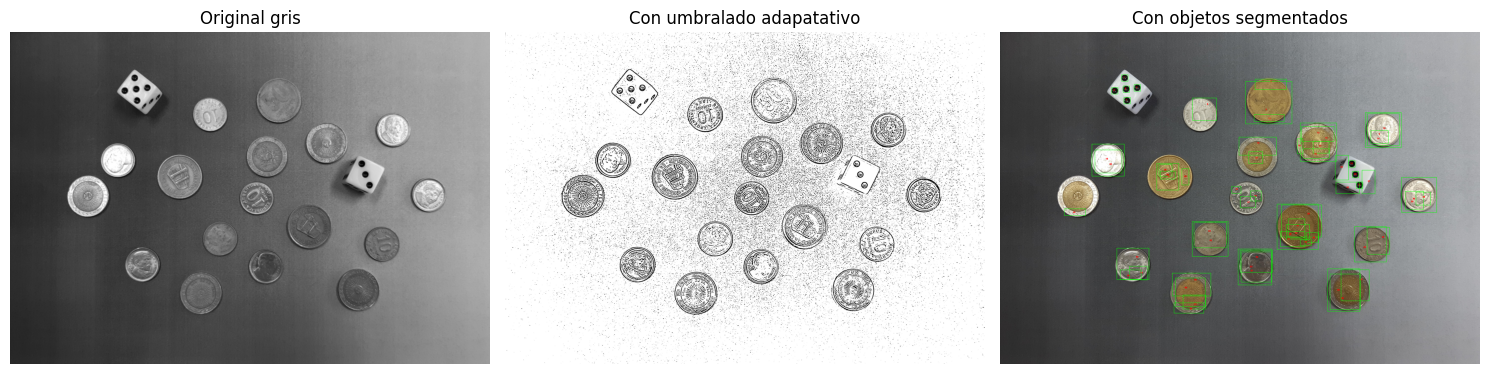

In [17]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.imshow(img_gris_blur, cmap='gray')
plt.title('Original gris')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_umbralado_blancos, cmap='gray')
plt.title('Con umbralado adapatativo')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(copia_img, cv2.COLOR_BGR2RGB))
plt.title('Con objetos segmentados')
plt.axis('off')

plt.tight_layout()
plt.show()